In [12]:
import os
import numpy as np
from PIL import Image
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import random

In [92]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Image transform (resize and grayscale)
transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.Grayscale(),
    transforms.ToTensor()
])

In [94]:
train_dataset = datasets.ImageFolder("/home/deep/Documents/ISIC2016 original/train/", transform=transform)
test_dataset = datasets.ImageFolder("/home/deep/Documents/ISIC2016 original/test/", transform=transform)

In [96]:
def dataset_to_numpy(dataset):
    X = []
    y = []
    for img, label in dataset:
        X.append(img.view(-1).numpy())  # flatten
        y.append(label)
    return np.array(X), np.array(y)

X_train, y_train = dataset_to_numpy(train_dataset)
X_test, y_test = dataset_to_numpy(test_dataset)
class_labels = train_dataset.classes 

In [97]:
class NaiveBayes:
    def fit(self, X, y):
        self.classes = np.unique(y)
        self.mean = {}
        self.var = {}
        self.priors = {}

        for cls in self.classes:
            X_c = X[y == cls]
            self.mean[cls] = np.mean(X_c, axis=0)
            self.var[cls] = np.var(X_c, axis=0) + 1e-6  # avoid divide-by-zero
            self.priors[cls] = X_c.shape[0] / X.shape[0]

    def gaussian_pdf(self, class_idx, x):
        mean = self.mean[class_idx]
        var = self.var[class_idx]
        numerator = np.exp(-((x - mean) ** 2) / (2 * var))
        denominator = np.sqrt(2 * np.pi * var)
        return numerator / denominator

    def predict(self, X):
        y_pred = []
        for x in X:
            posteriors = []
            for cls in self.classes:
                prior = np.log(self.priors[cls])
                conditional = np.sum(np.log(self.gaussian_pdf(cls, x)))
                posteriors.append(prior + conditional)
            y_pred.append(self.classes[np.argmax(posteriors)])
        return np.array(y_pred)

In [98]:
model = NaiveBayes()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [99]:
accuracy = np.mean(y_pred == y_test)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.6860


In [100]:
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=class_labels))


Confusion Matrix:
 [[231  73]
 [ 46  29]]

Classification Report:
               precision    recall  f1-score   support

         ben       0.83      0.76      0.80       304
         mel       0.28      0.39      0.33        75

    accuracy                           0.69       379
   macro avg       0.56      0.57      0.56       379
weighted avg       0.73      0.69      0.70       379



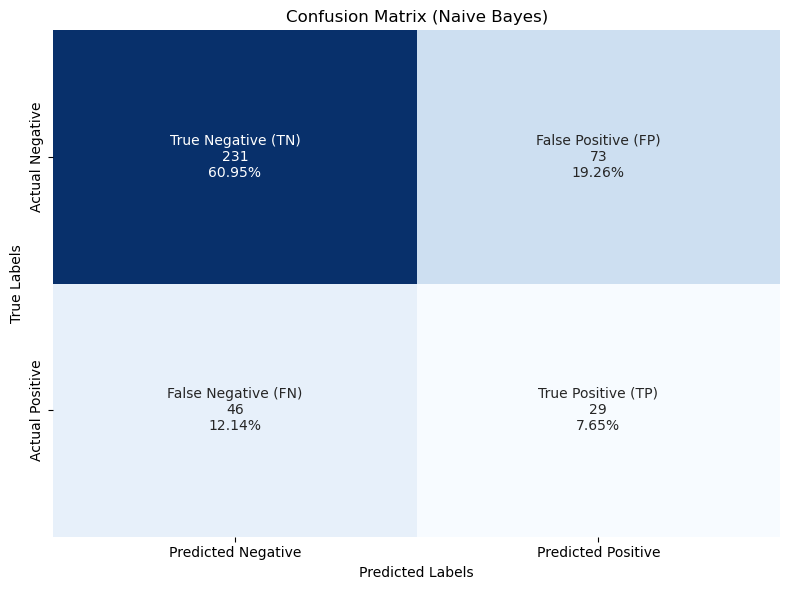


From Confusion Matrix:
Precision : 0.2843
Recall :    0.3867
F1 Score :  0.3277


In [101]:
import seaborn as sns

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_confusion_matrix(cm, title='Confusion Matrix'):
    group_names = ['True Negative (TN)', 'False Positive (FP)',
                   'False Negative (FN)', 'True Positive (TP)']
    group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]

    labels = [f"{name}\n{count}\n{percent}" for name, count, percent in zip(group_names, group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(2, 2)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False,
                xticklabels=['Predicted Negative', 'Predicted Positive'],
                yticklabels=['Actual Negative', 'Actual Positive'])
    plt.title(title)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.tight_layout()
    plt.show()

# Call the function
plot_confusion_matrix(cm, title="Confusion Matrix (Naive Bayes)")

def compute_metrics_from_cm(cm):
    TN, FP, FN, TP = cm.ravel()

    precision = TP / (TP + FP) if (TP + FP) else 0
    recall = TP / (TP + FN) if (TP + FN) else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) else 0

    return precision, recall, f1

# Calculate metrics
precision, recall, f1 = compute_metrics_from_cm(cm)
print(f"\nFrom Confusion Matrix:")
print(f"Precision : {precision:.4f}")
print(f"Recall :    {recall:.4f}")
print(f"F1 Score :  {f1:.4f}")
